## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [3]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']

## 2. Main reproduction - Model 1: POSm4

In [2]:
def func_POSm4_fix(x, klin, knonlin):
    fb = 1 + (x[3] / knonlin[0])**knonlin[1]
    dx = np.zeros(4)
    dx[0] = klin[0] - klin[1] * x[0] * fb - klin[2] * x[0]
    dx[1] = klin[1] * x[0] * fb - klin[3] * x[1] - klin[4] * x[1]
    dx[2] = klin[3] * x[1] - klin[5] * x[2] - klin[6] * x[2]
    dx[3] = klin[5] * x[2] - klin[7] * x[3]
    return dx

def solve_POSm4(initial_conditions, time_points, klin, knonlin):
    def model(x, t):
        return func_POSm4_fix(x, klin, knonlin)
    sol = odeint(model, initial_conditions, time_points)
    return sol

In [20]:
# Parameters from supplementary material
klin = (150, 0.04, 0.3, 500, 5000, 80, 4, 5)
knonlin = (0.3, 2)
s_star = [1,2,3,4]

# Parameters not yet in supplement data
perturbation_point = 8.6

In [16]:
# Jacocbian calculation
j_matrix = numdifftools.Jacobian(lambda x: func_POSm4_fix(x, klin, knonlin),method="central")(s_star)
signed_jacobian = np.sign(j_matrix)

In [17]:
print("Jacobian matrix:")
print(j_matrix)
print("Signed Jacobian matrix:")
print(signed_jacobian)

Jacobian matrix:
[[-8.13622222e+00  0.00000000e+00  0.00000000e+00 -3.91111111e+00]
 [ 7.86622222e+00 -5.55000000e+03  0.00000000e+00  3.91111111e+00]
 [ 0.00000000e+00  5.50000000e+02 -8.24000000e+01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  7.80000000e+01 -5.10000000e+00]]
Signed Jacobian matrix:
[[-1.  0.  0. -1.]
 [ 1. -1.  0.  1.]
 [ 0.  1. -1.  0.]
 [ 0.  0.  1. -1.]]


In [19]:
# Find loops
res_tab = ld.find_loops_vset(func_POSm4_fix,vset=[s_star],klin=klin,
                   knonlin=knonlin,max_num_loops=10)
res_tab['loop_rep'][0]

,loop,length,sign
0,"(0, 1, 2, 3, 0)",4,-1
1,"(1, 2, 3, 1)",3,1
2,"(0, 0)",1,-1
3,"(1, 1)",1,-1
4,"(2, 2)",1,-1
5,"(3, 3)",1,-1


In [34]:
loop_list = ld.find_loops(j_matrix)
ld.loop_summary(loop_list)

length,1,3,4
total,4,1,1
neg,4,0,1
pos,0,1,0


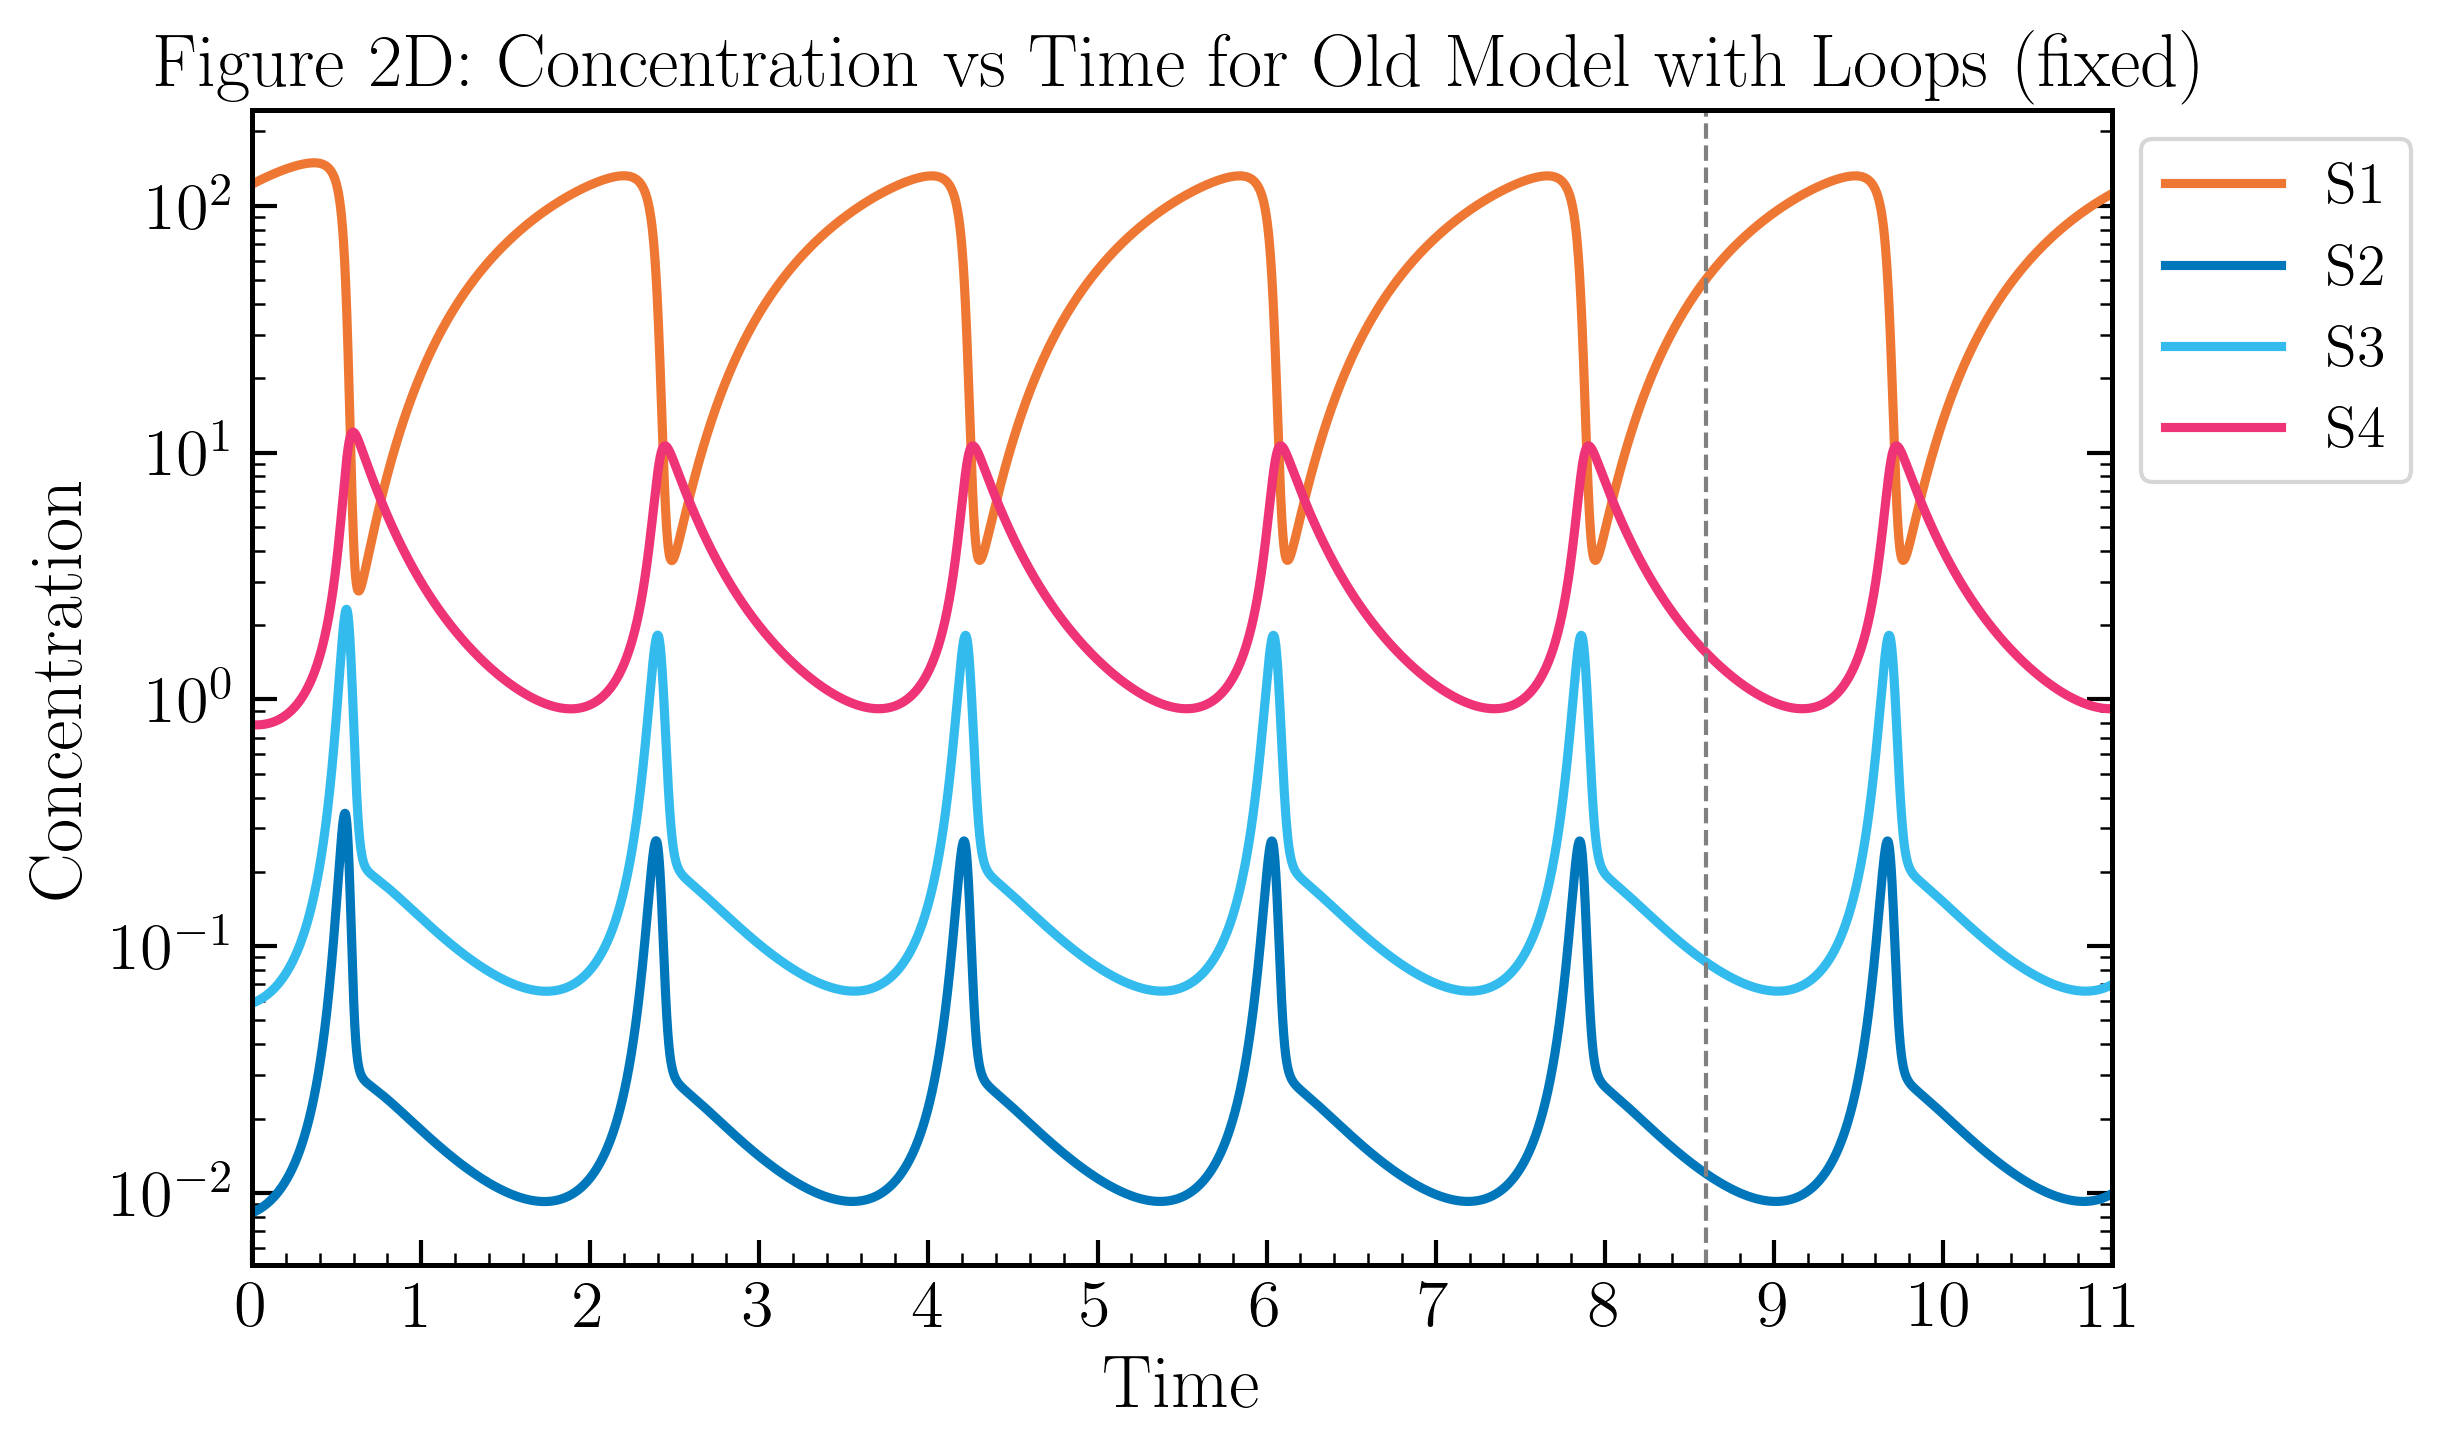

In [24]:
# Draw plot concentration vs time for the old model with loops (fixed)
# Make time points longer to stabilize the dynamics of the system
time_points = np.linspace(0, 13, 13001) # delta t = 0.001
initial_conditions = s_star
sol = solve_POSm4(initial_conditions, time_points,
                        klin=klin, knonlin=knonlin)
start_index = int(1.2 / 0.001)
time_ranges = time_points[start_index:]-time_points[start_index]
data_ranges = sol[start_index:, :]

plt.figure(figsize=(8, 5)) 
for i, c in enumerate(colors[:4]):
    plt.plot(time_ranges, data_ranges[:, i], lw=2.2, color=c, label=f"S{i+1}")

plt.axvline(x=perturbation_point, color='gray', linestyle='--', lw=1)
plt.xlabel('Time')
plt.xlim(0, 11)
plt.xticks(np.arange(0, 12, 1))
plt.ylabel('Concentration')
plt.gca().yaxis.set_ticks_position('both')
plt.yscale('log')
plt.title('Figure 2D: Concentration vs Time for Old Model with Loops (fixed)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

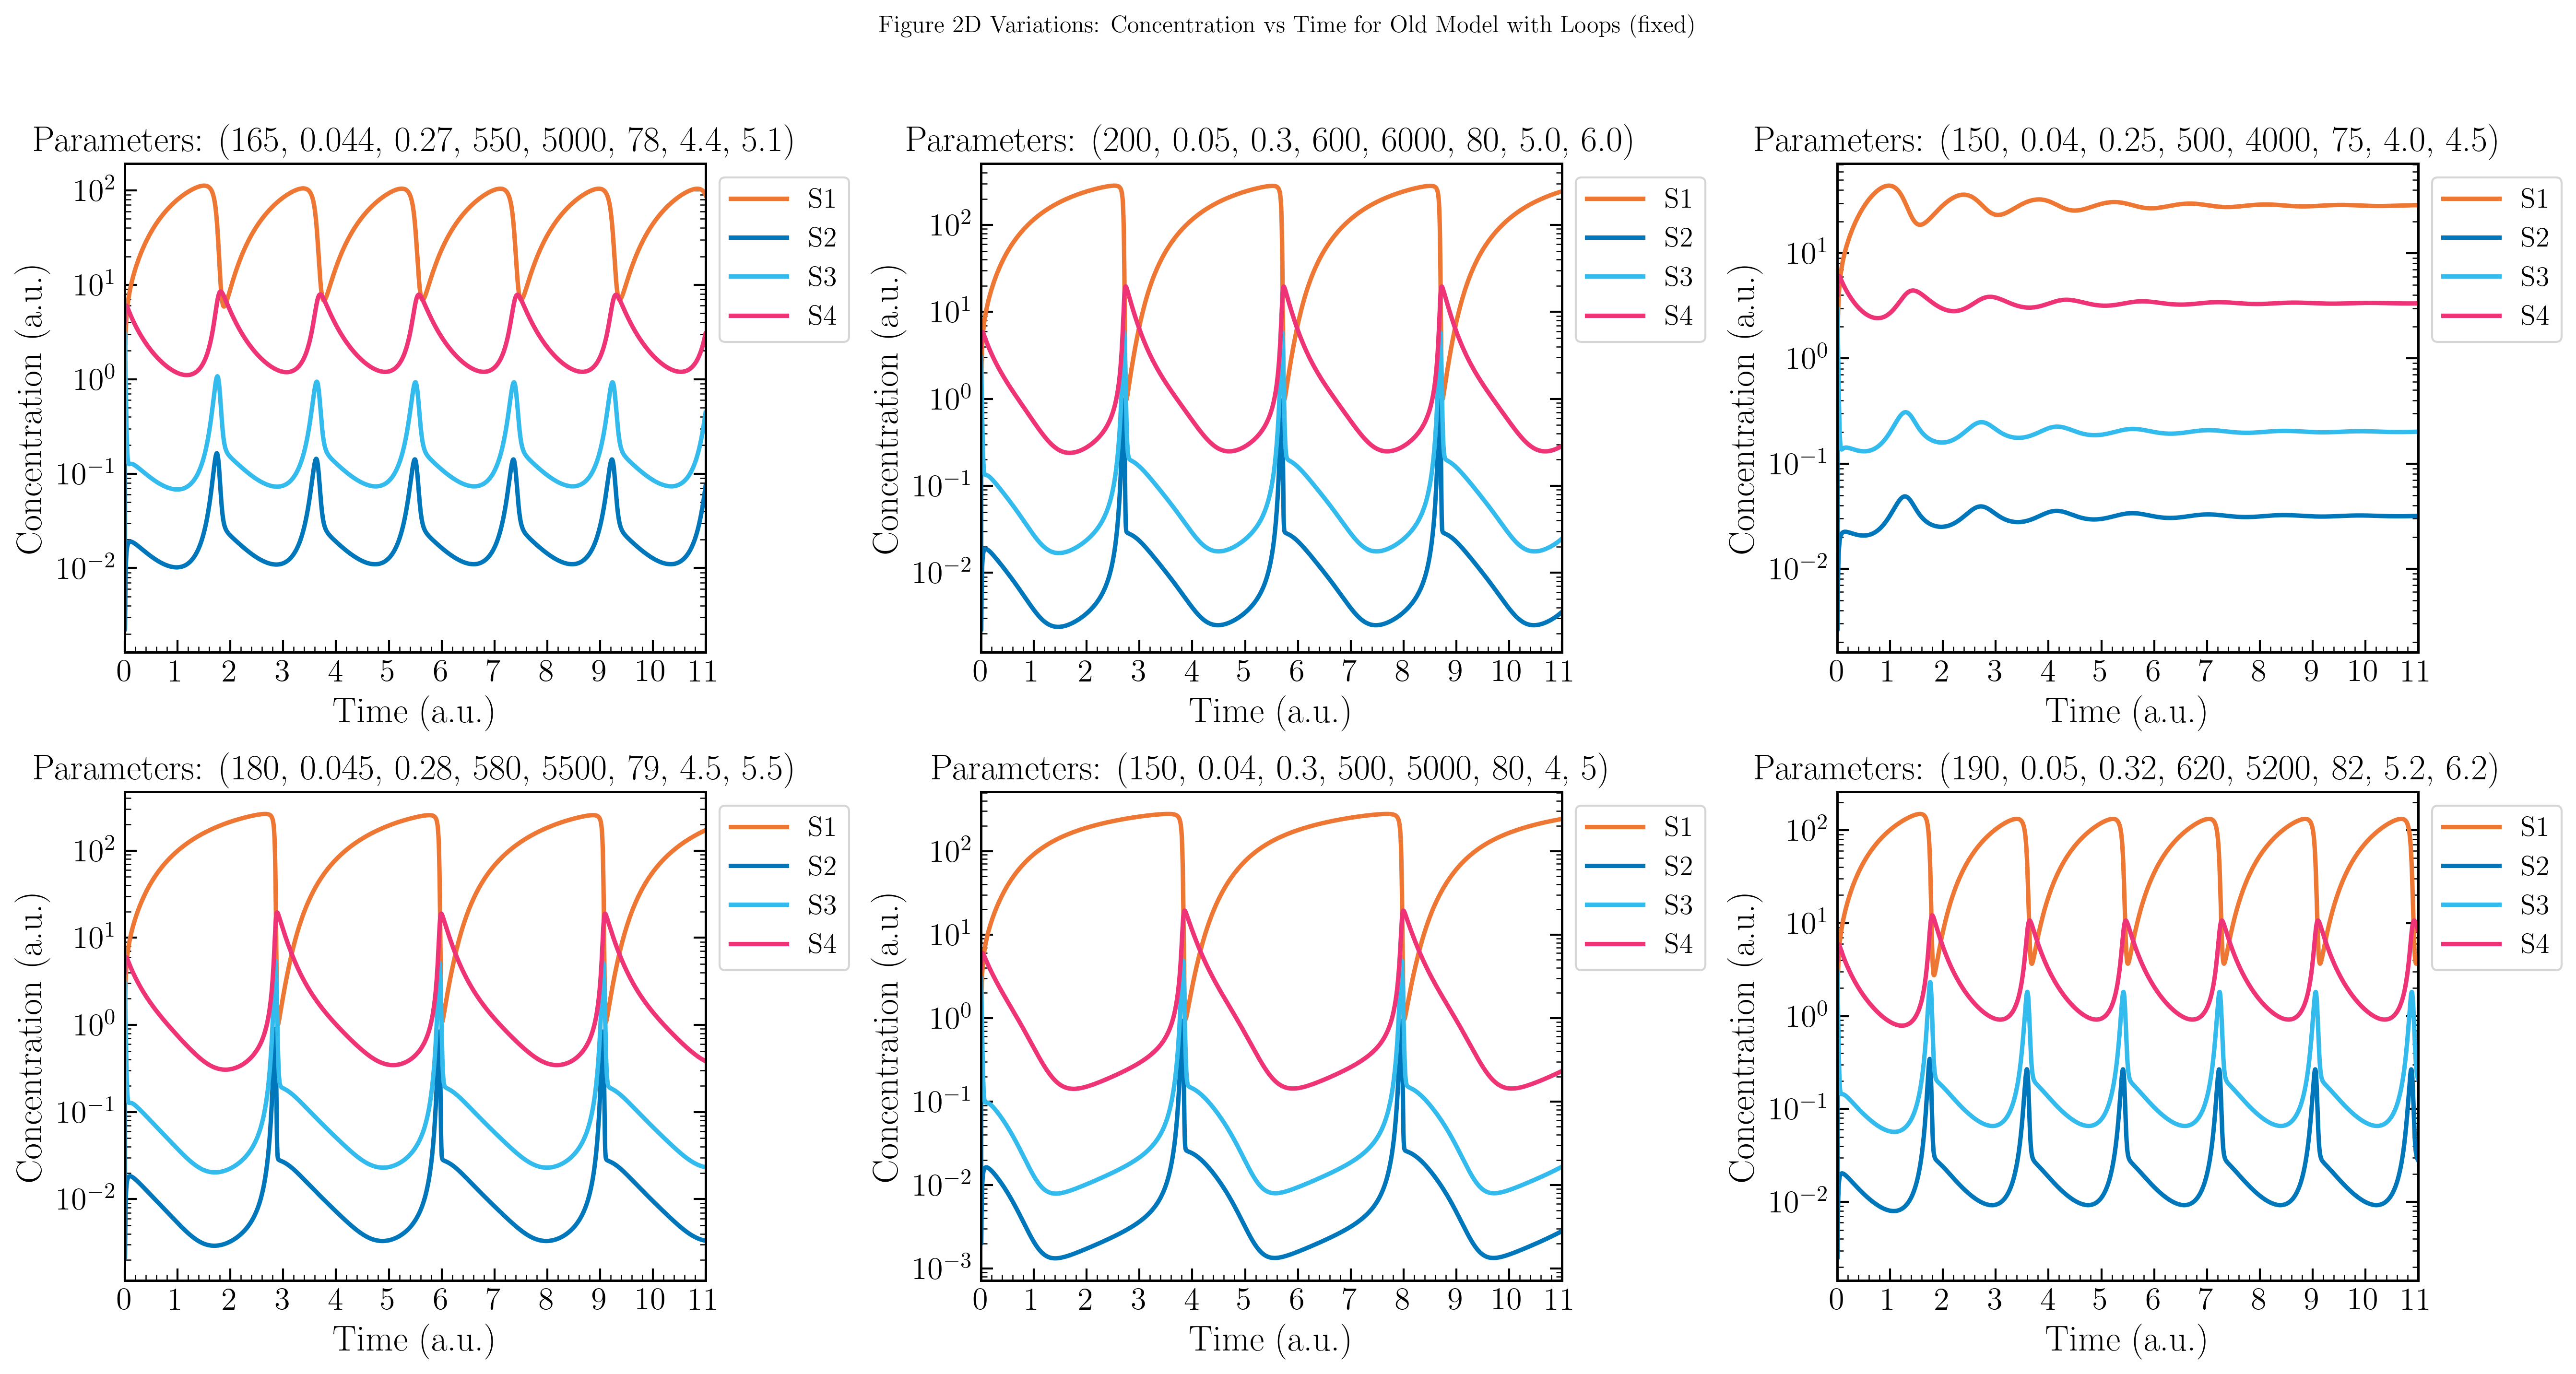

In [22]:
# Try different parameters to see variations
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
param_sets = [
    (165, 0.044, 0.27, 550, 5000, 78, 4.4, 5.1),
    (200, 0.05, 0.3, 600, 6000, 80, 5.0, 6.0),
    (150, 0.04, 0.25, 500, 4000, 75, 4.0, 4.5),
    (180, 0.045, 0.28, 580, 5500, 79, 4.5, 5.5),
    (150, 0.04, 0.3, 500, 5000, 80, 4, 5),
    (190, 0.05, 0.32, 620, 5200, 82, 5.2, 6.2)
]
for ax, params in zip(axs.flatten(), param_sets):
    klin = params
    sol = solve_POSm4(initial_conditions, time_points,
                            klin=klin, knonlin=knonlin)
    for i, c in enumerate(colors[:4]):
        ax.plot(time_points, sol[:, i], lw=2.2, color=c, label=f"S{i+1}")
    # ax.plot(time_points, sol, label=['S1', 'S2', 'S3', 'S4'])
    ax.set_xlabel('Time (a.u.)', weight='bold')
    ax.set_xlim(0, 11)
    ax.set_xticks(np.arange(0, 12, 1))
    # Show tick marks in both left and right y-axes
    ax.yaxis.set_ticks_position('both')
    ax.set_ylabel('Concentration (a.u.)', weight='bold')
    ax.set_yscale('log')
    ax.set_title(f'Parameters: {params}')
    # Make legend outside the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # ax.legend()
plt.suptitle('Figure 2D Variations: Concentration vs Time for Old Model with Loops (fixed)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#Show in 300 dpi
plt.gcf().set_dpi(300)
plt.show()

In [26]:
# Perturbation at t=8.6

# Parameters (Not yet in supplement data)
delta_t = 0.001
perturbation_point = 8.6 # start perturbation at t=8.6 a.u.
time_index = int(perturbation_point/delta_t) + start_index
initial_cond_POSm4 = sol[time_index, :]  
cap_range = 0.05  # time range to capture before and after perturbation
sol_1 = sol[time_index - int(cap_range/delta_t):time_index + 1, :]  # from t=8.1 to t=9.1
time_points_1 = np.linspace(-cap_range, 0, int(cap_range/delta_t) + 1)  # from -0.5 to 0
time_points_2 = np.linspace(0, cap_range, int(cap_range/delta_t) + 1)  # from 0 to 0.5
initial_cond_perturbed = [initial_cond_POSm4[0], initial_cond_POSm4[1], initial_cond_POSm4[2], 0.75]  # perturb S4 to 0.75
sol_2 = solve_POSm4(initial_cond_perturbed, time_points_2, klin=klin, knonlin=knonlin)

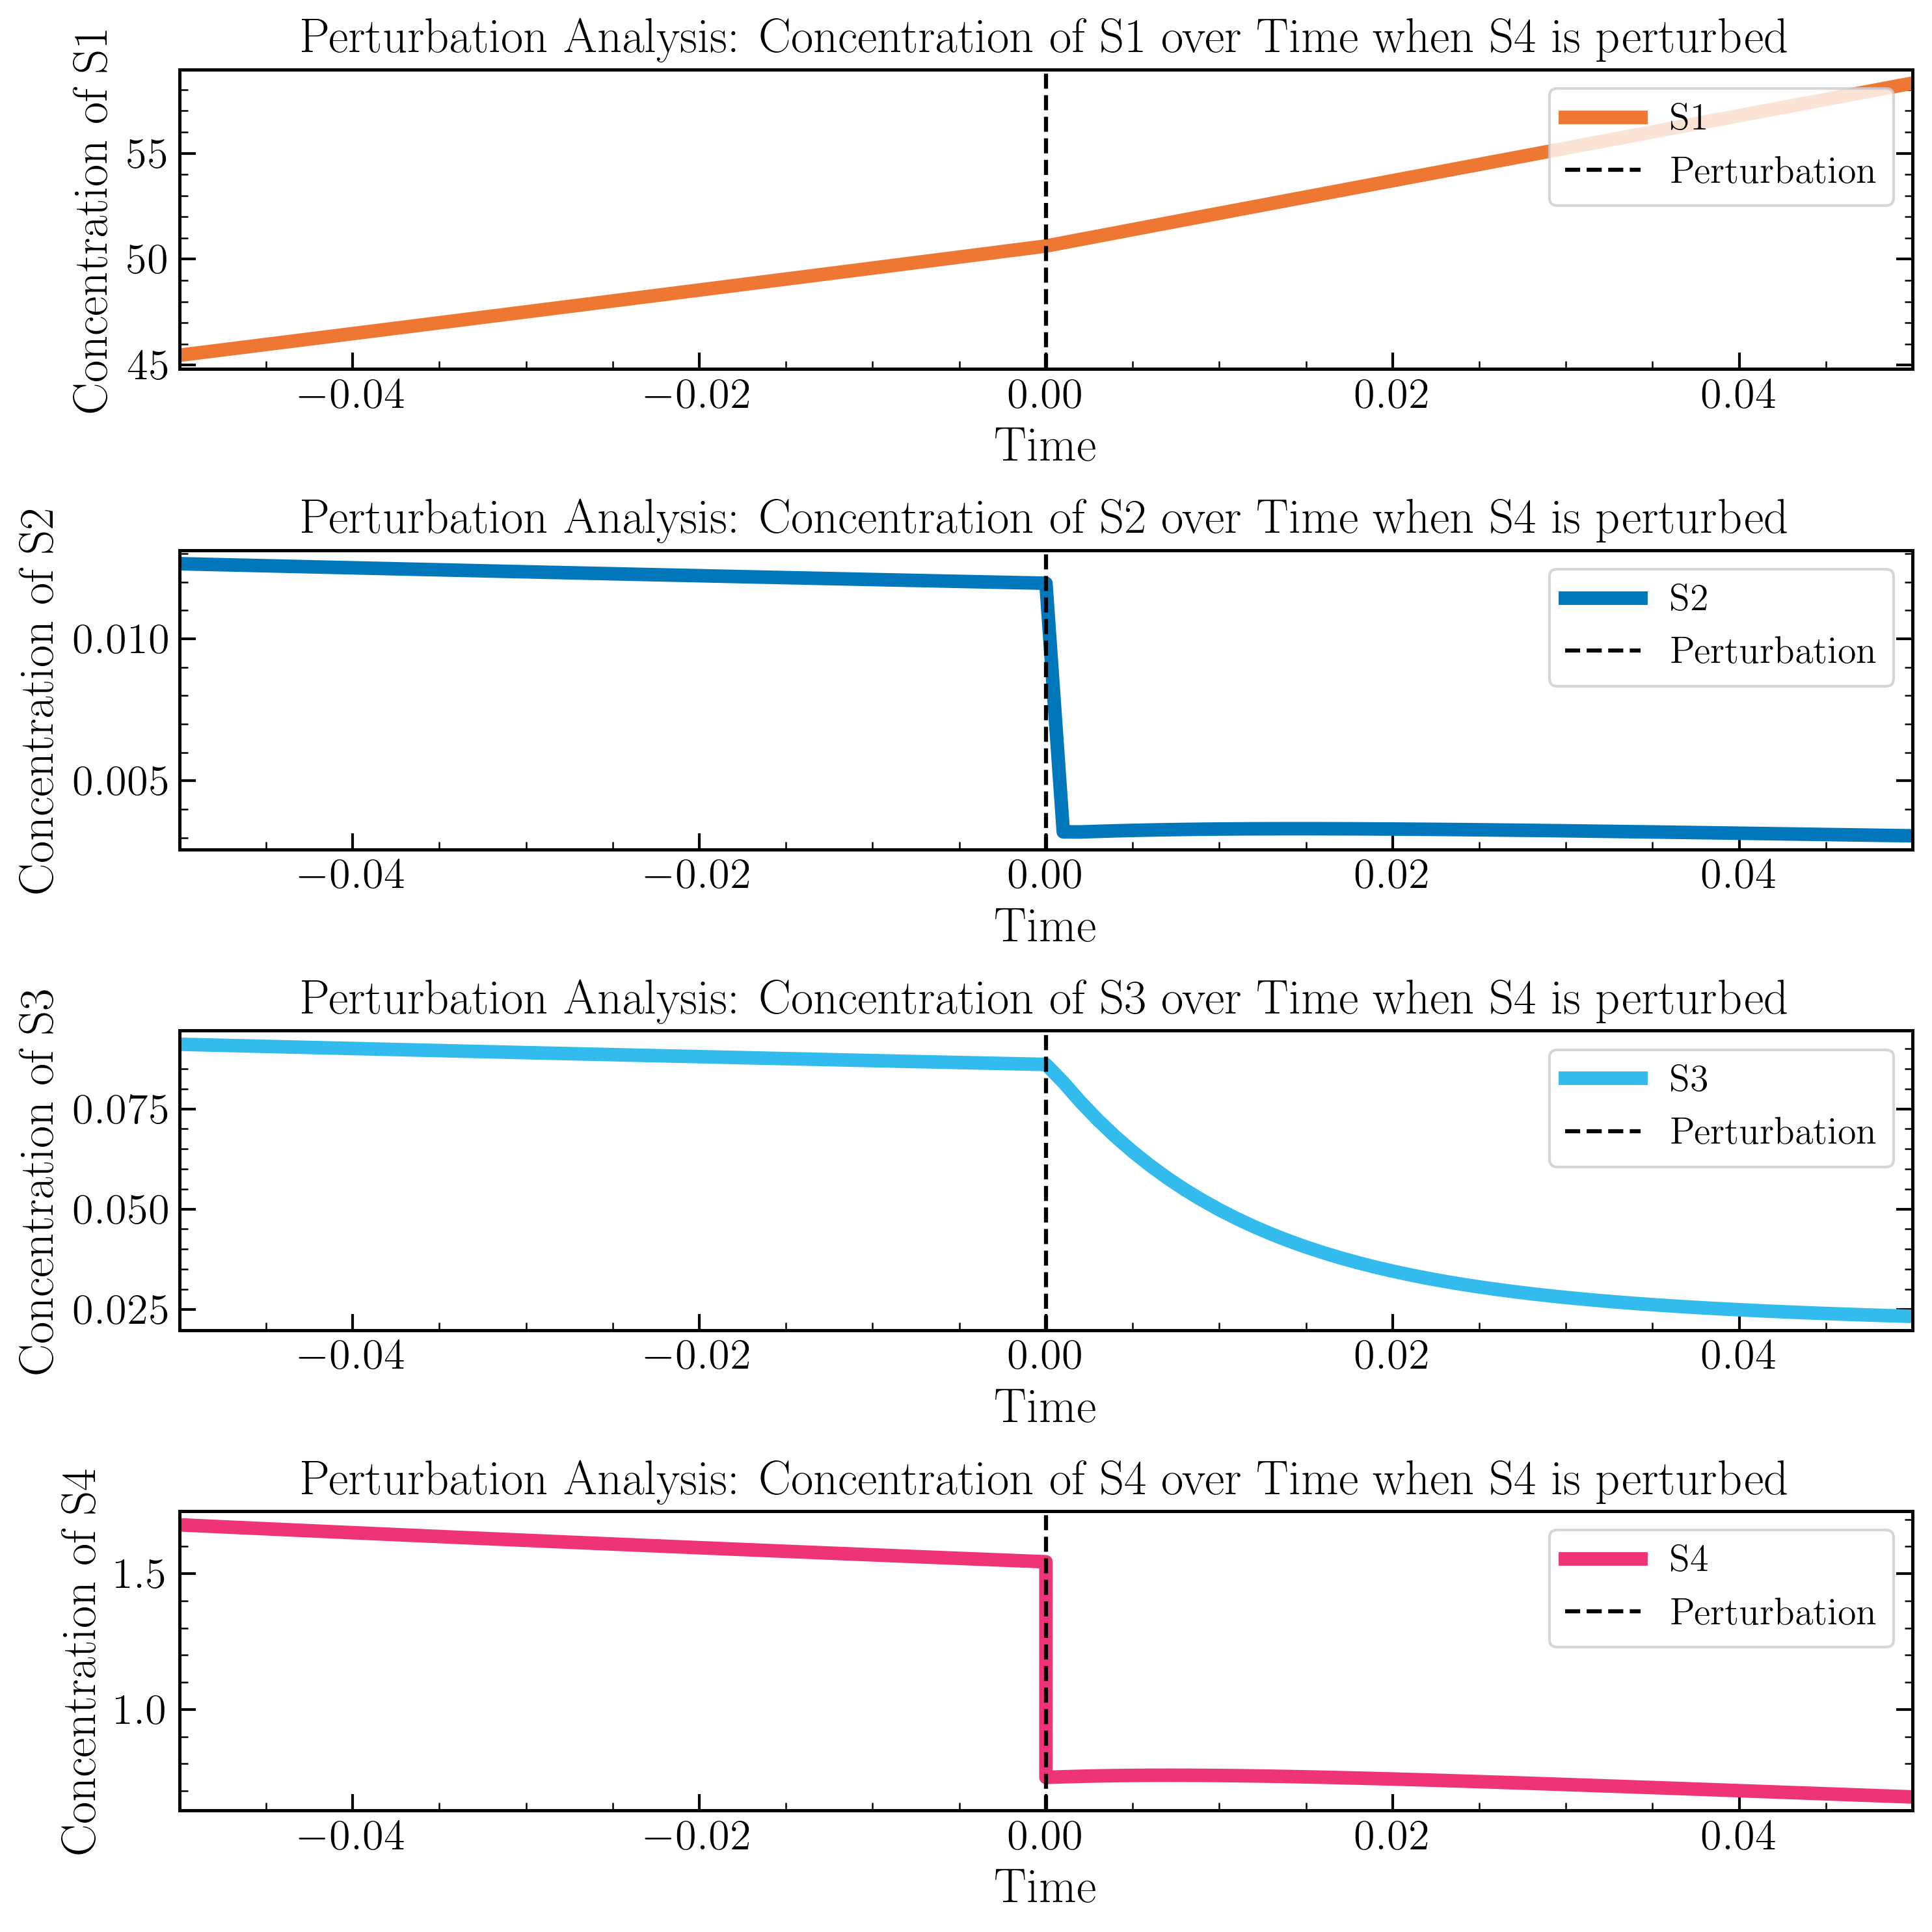

In [27]:
# Plot pertubation results (4 plots for S1, S2, S3, S4 in one figure)
fig, axs = plt.subplots(4, 1, figsize=(10, 10))
# Plot for S1
time_S1 = np.concatenate((time_points_1, time_points_2))
value_S1 = np.concatenate((sol_1[:, 0], sol_2[:, 0]))
axs[0].plot(time_S1, value_S1, lw=5, color=colors[0], label='S1')
# Black dashed line at t=0.0
axs[0].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Concentration of S1')
axs[0].set_title('Perturbation Analysis: Concentration of S1 over Time when S4 is perturbed')
axs[0].set_xlim(-cap_range, cap_range)
axs[0].yaxis.set_ticks_position('both')
# axs[0].set_xticks(np.arange(-cap_range, cap_range + delta_t, delta_t))
axs[0].legend(loc='upper right')
# Plot for S2
time_S2 = np.concatenate((time_points_1, time_points_2))
value_S2 = np.concatenate((sol_1[:, 1], sol_2[:, 1]))
axs[1].plot(time_S2, value_S2, lw=5, color=colors[1], label='S2')
# Black dashed line at t=0.0
axs[1].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Concentration of S2')
axs[1].set_title('Perturbation Analysis: Concentration of S2 over Time when S4 is perturbed')
axs[1].set_xlim(-cap_range, cap_range)
axs[1].yaxis.set_ticks_position('both')
# axs[1].set_xticks(np.arange(-cap_range, cap_range + delta_t, delta_t))
axs[1].legend(loc='upper right')
# Plot for S3
time_S3 = np.concatenate((time_points_1, time_points_2))
value_S3 = np.concatenate((sol_1[:, 2], sol_2[:, 2]))
axs[2].plot(time_S3, value_S3, lw=5, color=colors[2], label='S3')
# Black dashed line at t=0.0
axs[2].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Concentration of S3')
axs[2].set_title('Perturbation Analysis: Concentration of S3 over Time when S4 is perturbed')
axs[2].set_xlim(-cap_range, cap_range)
axs[2].yaxis.set_ticks_position('both')
# axs[2].set_xticks(np.arange(-cap_range, cap_range + delta_t, delta_t))
axs[2].legend(loc='upper right')
# Plot for S4
time_S4 = np.concatenate((time_points_1, time_points_2))
value_S4 = np.concatenate((sol_1[:, 3], sol_2[:, 3]))
axs[3].plot(time_S4, value_S4, lw=5, color=colors[3], label='S4')
# Black dashed line at t=0.0
axs[3].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Concentration of S4')
axs[3].set_title('Perturbation Analysis: Concentration of S4 over Time when S4 is perturbed')
axs[3].set_xlim(-cap_range, cap_range)
axs[3].yaxis.set_ticks_position('both')
# axs[3].set_xticks(np.arange(-cap_range, cap_range + delta_t, delta_t))
axs[3].legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [31]:
id_to_subject = {
    0: "S1",
    1: "S2",
    2: "S3",
    3: "S4"
}

df = pd.DataFrame(res_tab['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df

,loop,length,sign,loop_subject
2,"(0, 0)",1,-1,"(S1, S1)"
3,"(1, 1)",1,-1,"(S2, S2)"
4,"(2, 2)",1,-1,"(S3, S3)"
5,"(3, 3)",1,-1,"(S4, S4)"
1,"(1, 2, 3, 1)",3,1,"(S2, S3, S4, S2)"
0,"(0, 1, 2, 3, 0)",4,-1,"(S1, S2, S3, S4, S1)"


### 3.2. Represent regulation relationship from Jacobian matrix

In [33]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

regulation_info = pd.DataFrame(signed_jacobian, columns=[id_to_subject[i] for i in range(signed_jacobian.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info

,from,to,regulation,regulation_words
0,S1,S1,-1.0,inhibition (negative)
1,S1,S2,0.0,no regulation
2,S1,S3,0.0,no regulation
3,S1,S4,-1.0,inhibition (negative)
4,S2,S1,1.0,activation (positive)
5,S2,S2,-1.0,inhibition (negative)
6,S2,S3,0.0,no regulation
7,S2,S4,1.0,activation (positive)
8,S3,S1,0.0,no regulation
9,S3,S2,1.0,activation (positive)


### 3.3. Loop Summary in more detail

In [ ]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
2,"(0, 0)",1,-1,"(S1, S1)"
3,"(1, 1)",1,-1,"(S2, S2)"
4,"(2, 2)",1,-1,"(S3, S3)"
5,"(3, 3)",1,-1,"(S4, S4)"
1,"(1, 2, 3, 1)",3,1,"(S2, S3, S4, S2)"
0,"(0, 1, 2, 3, 0)",4,-1,"(S1, S2, S3, S4, S1)"


In [36]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,4,"[(S1, S1), (S2, S2), (S3, S3), (S4, S4)]"
1,3,1,"[(S2, S3, S4, S2)]"
2,4,1,"[(S1, S2, S3, S4, S1)]"


In [39]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,4,"[(S1, S1), (S2, S2), (S3, S3), (S4, S4)]",4,0,"[(S1, S1), (S2, S2), (S3, S3), (S4, S4)]",[]
1,3,1,"[(S2, S3, S4, S2)]",0,1,[],"[(S2, S3, S4, S2)]"
2,4,1,"[(S1, S2, S3, S4, S1)]",0,1,[],"[(S1, S2, S3, S4, S1)]"


In [41]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,4,4,0,"[(S1, S1), (S2, S2), (S3, S3), (S4, S4)]","[(S1, S1), (S2, S2), (S3, S3), (S4, S4)]",[]
1,3,1,0,1,"[(S2, S3, S4, S2)]",[],"[(S2, S3, S4, S2)]"
2,4,1,0,1,"[(S1, S2, S3, S4, S1)]",[],"[(S1, S2, S3, S4, S1)]"


## 4. Code that write but didn't use any more

In [ ]:
# Pertubation analysis

def pertubation_analysis(initial_conditions, time_points, klin, knonlin, perturbation_point, perturbation_magnitude):
    def model(t, x):
        return func_POSm4_fix(x, klin, knonlin)
    
    def event(t, x):
        return t - perturbation_point
    event.terminal = True
    event.direction = 1

    sol1 = solve_ivp(model, [time_points[0], perturbation_point], initial_conditions,
                     t_eval=time_points[time_points <= perturbation_point],
                     events=event, method='RK45')
    
    perturbed_state = sol1.y[:, -1] * perturbation_magnitude
    
    sol2 = solve_ivp(model, [perturbation_point, time_points[-1]], perturbed_state,
                     t_eval=time_points[time_points > perturbation_point],
                     method='RK45')
    
    full_time = np.concatenate((sol1.t, sol2.t))
    full_sol = np.hstack((sol1.y, sol2.y))
    
    return full_time, full_sol
time_points = np.linspace(0, 13, 13001) # delta t = 0.001
initial_conditions = s_star
full_time, full_sol = pertubation_analysis(initial_conditions, time_points,
                                           klin, knonlin,
                                           perturbation_point,
                                           perturbation_magnitude=1.5)
start_index = int(1.2 / 0.001)
time_ranges = full_time[start_index:] - full_time[start_index]
data_ranges = full_sol[:, start_index:].T
plt.figure(figsize=(8, 5))
for i, c in enumerate(colors[:4]):
    plt.plot(time_ranges, data_ranges[:, i], lw=2.2, color=c, label=f"S{i+1}")
plt.axvline(x=perturbation_point, color='gray', linestyle='--', lw=1)
plt.xlabel('Time')
plt.xlim(0, 11)
plt.xticks(np.arange(0, 12, 1))
plt.ylabel('Concentration')
plt.gca().yaxis.set_ticks_position('both')
plt.yscale('log')
plt.title('Perturbation Analysis: Concentration vs Time for Old Model with Loops (fixed)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

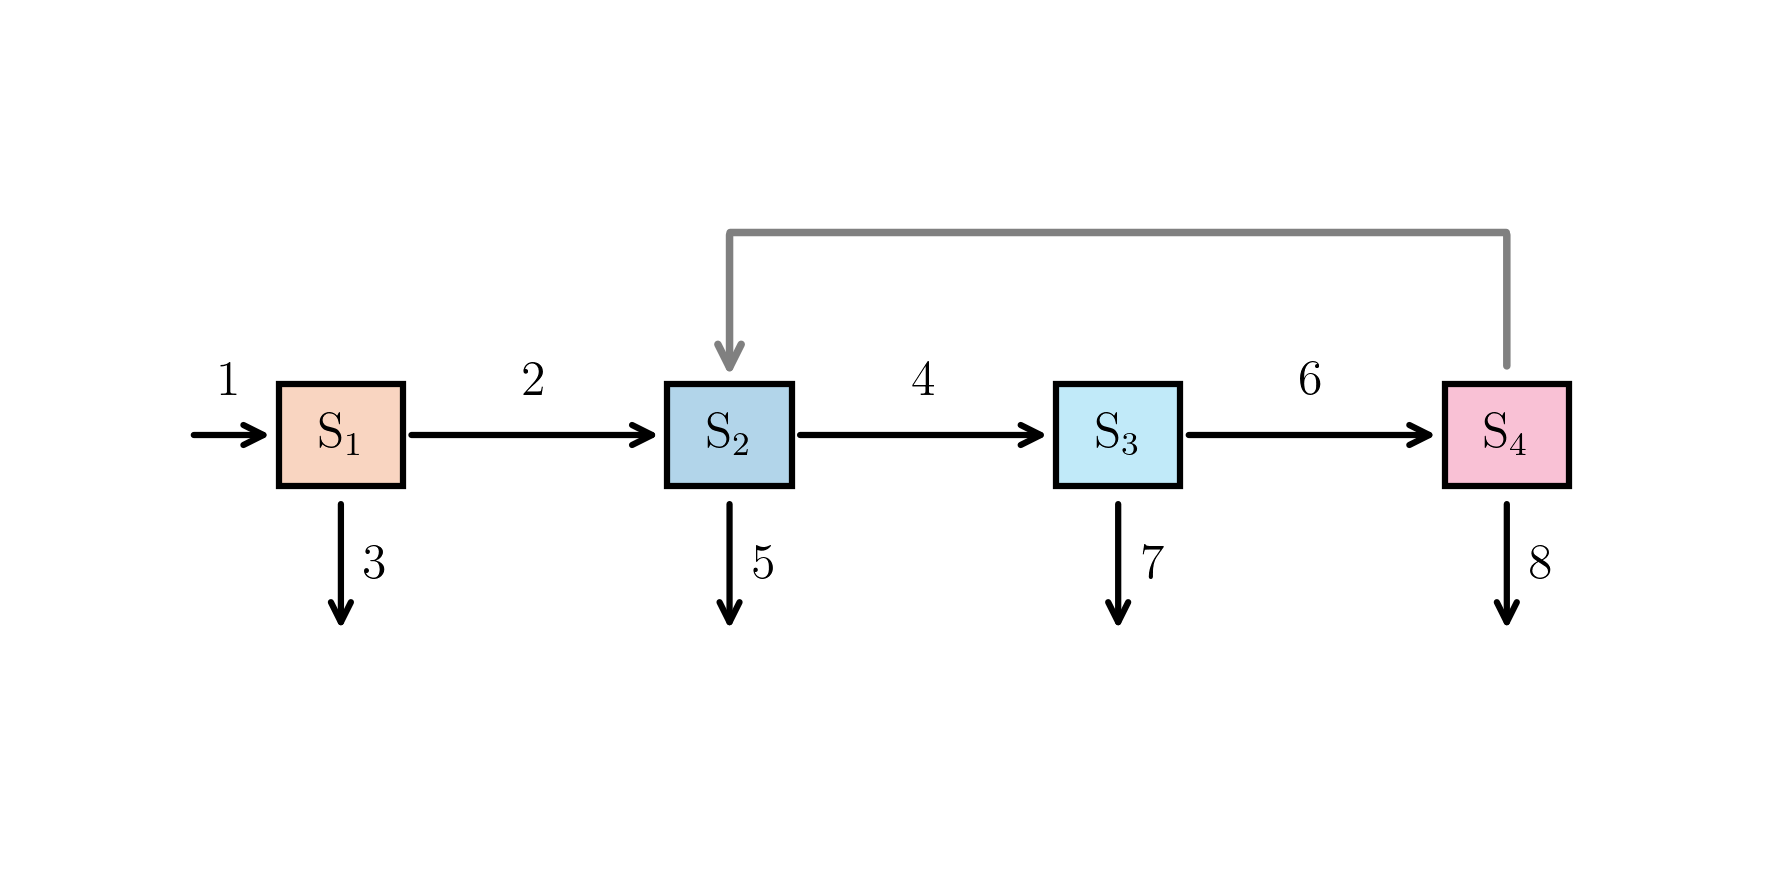

In [30]:
from matplotlib.patches import FancyArrowPatch, Rectangle

# ---------------------------------------------------------
# Helper function: draw a state box with label
# ---------------------------------------------------------
def draw_state(ax, center, label, color):
    x, y = center
    w, h = 0.8, 0.5
    rect = Rectangle((x - w/2, y - h/2), w, h,
                     linewidth=1.5, edgecolor=None,
                     facecolor=color, alpha=0.3)
    rect_2 = Rectangle((x - w/2, y - h/2), w, h,
                     linewidth=1.5, edgecolor="black",
                     fill=False)
    ax.add_patch(rect)
    ax.add_patch(rect_2)
    ax.text(x, y, label, ha="center", va="center", fontsize=12)
    return (x, y, w, h)

# ---------------------------------------------------------
# Helper: draw straight arrow between two centers
# ---------------------------------------------------------
def arrow(ax, start, end, text=None, y_offset=0.0):
    x1, y1 = start
    x2, y2 = end
    arr = FancyArrowPatch(
        (x1, y1 + y_offset), (x2, y2 + y_offset),
        arrowstyle='->', mutation_scale=12, linewidth=1.5, color='black'
    )
    ax.add_patch(arr)
    if text:
        ax.text((x1+x2)/2, y1 + y_offset + 0.15, text,
                ha="center", va="bottom", fontsize=12)

fig, ax = plt.subplots(figsize=(6, 3))

# Node positions (all on same horizontal line)
y0 = 0
S1 = draw_state(ax, (0, y0), "S$_1$", colors[0])
S2 = draw_state(ax, (2.5, y0), "S$_2$", colors[1])
S3 = draw_state(ax, (5.0, y0), "S$_3$", colors[2])
S4 = draw_state(ax, (7.5, y0), "S$_4$", colors[3])

# ---------------------------------------------------------
# Straight horizontal arrows (1→S1, S1→S2, S2→S3, S3→S4)
# ---------------------------------------------------------
arrow(ax, (-1.0, y0), (S1[0]-0.4, y0), "1")        # left input
arrow(ax, (S1[0]+0.4, y0), (S2[0]-0.4, y0), "2")
arrow(ax, (S2[0]+0.4, y0), (S3[0]-0.4, y0), "4")
arrow(ax, (S3[0]+0.4, y0), (S4[0]-0.4, y0), "6")

# Vertical output arrows (3, 5, 7, 8)
for (cx, cy, _, _), label in zip([S1, S2, S3, S4], ["3", "5", "7", "8"]):
    arr = FancyArrowPatch((cx, cy - 0.3), (cx, cy - 1.0),
                          arrowstyle='->', mutation_scale=12,
                          linewidth=1.5, color="black")
    ax.add_patch(arr)
    ax.text(cx + 0.15, cy - 0.65, label, fontsize=12, va="center")

# Example positions (use your own)
S1_pos = (0, 0)
S2_pos = (2.5, 0)
S3_pos = (5.0, 0)
S4_pos = (7.5, 0)

# Draw rectangular-corner feedback: S4 → S2
x4, y4 = S4_pos
x2, y2 = S2_pos

# Segment 1: Up
ax.add_patch(FancyArrowPatch(
    (x4, y4+0.3), (x4, y4 + 1.03),
    arrowstyle='-', linewidth=1.8, color="gray"))

# Segment 2: Left
ax.add_patch(FancyArrowPatch(
    (x4+0.05, y4 + 1), (x2-0.05, y2 + 1),
    arrowstyle='-', linewidth=1.8, color="gray"))

# Segment 3: Down with arrow head
ax.add_patch(FancyArrowPatch(
    (x2, y2 + 1.03), (x2, y2+0.25),
    arrowstyle='->', mutation_scale=14, linewidth=1.8, color="gray"))

ax.text((S4[0]+S2[0])/2, y0 + 1.0, "", fontsize=12)

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------
ax.set_xlim(-2, 9)
ax.set_ylim(-2, 2)
ax.axis("off")

plt.tight_layout()
plt.show()

